# Chromatin at replication time: Early vs Late Replicating Origins

May 3, 2024

**Goal:** Identify differences in early and late firing origins. What patterns or signals in the chromatin can be discerned at replication time. Are early replicating genes distinct from late replicating?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
repl_timing_file = 'datasets/computed_mnase/all_repl_timing_deconvolved.csv'
repl_timing = pd.read_csv(repl_timing_file).set_index('orf_name')
print(len(repl_timing), " genes with replication profiles")

repl_timing.head()


5250  genes with replication profiles


,timing,H_index
orf_name,,
YAL067W-A,53.314585,196
YAL067C,52.304185,194
YAL064C-A,52.809385,195
YAL064W,51.798985,193
YAL063C-A,51.798985,193


In [3]:
from src.replication_deconvolution_solver import plot_chrom_repl_timing_from_data

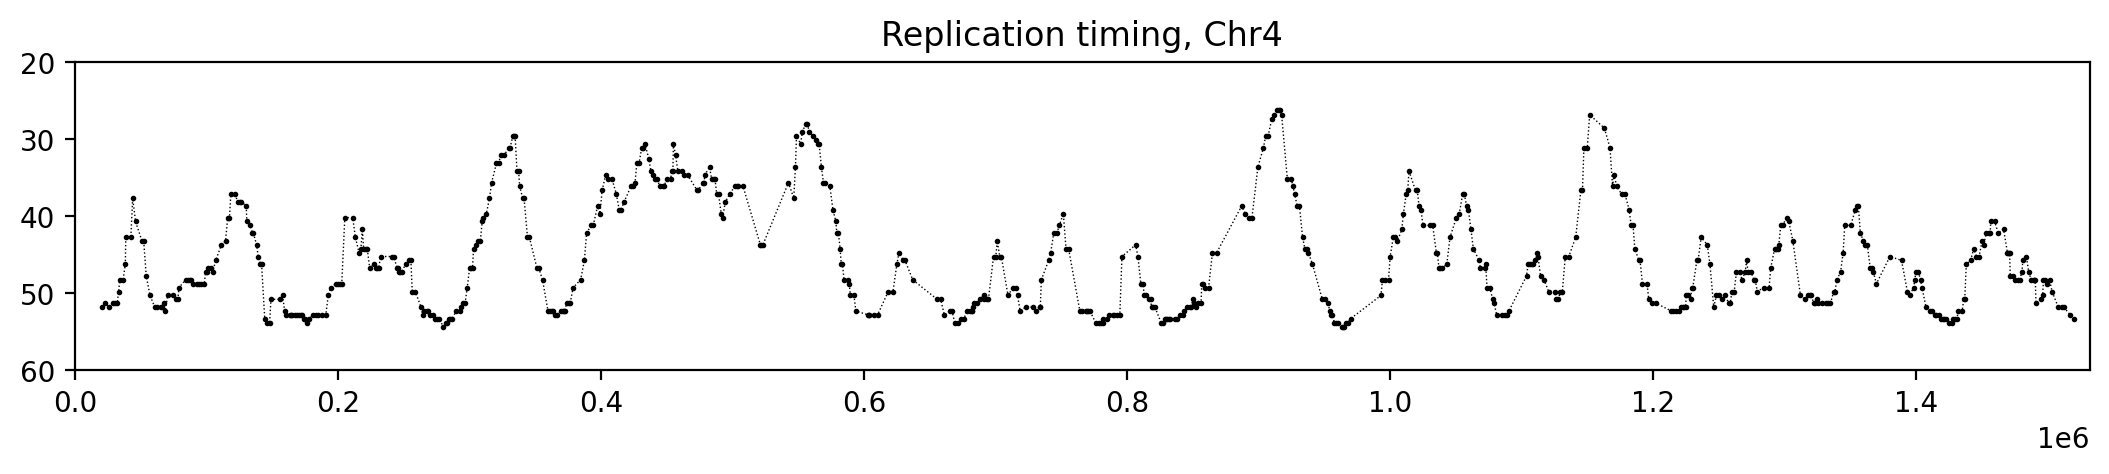

In [4]:
from src.geneset import get_deconvolved_geneset
geneset = get_deconvolved_geneset()

chrom = 4
plot_chrom_repl_timing_from_data(repl_timing, geneset, chrom)

In [5]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.007
1001/5574 - 00:00:04.983
2001/5574 - 00:00:10.744
3001/5574 - 00:00:16.201
4001/5574 - 00:00:21.734
5001/5574 - 00:00:27.584


In [6]:
promoter_analysis.correct_f_images_by_strand()

In [7]:
# Let's get the gene expression at the replication time.

from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()


# Which genes to start with?

Options:

Many genes, all genes compute the chromatin (some delta) before and after replication
- Prior-replication fork
- Post-replication fork

Early vs Late
High vs Low Gene expression


In [8]:
from src.gene_chromatin_replication_analysis import GeneChromatinReplicationAnalysis

gene_chrom_repl_analysis = GeneChromatinReplicationAnalysis(promoter_analysis,
                                                            ge_analysis,
                                                            repl_timing)

5232 genes with replication timing
Shape of the f images:  (5232, 227, 8, 25)


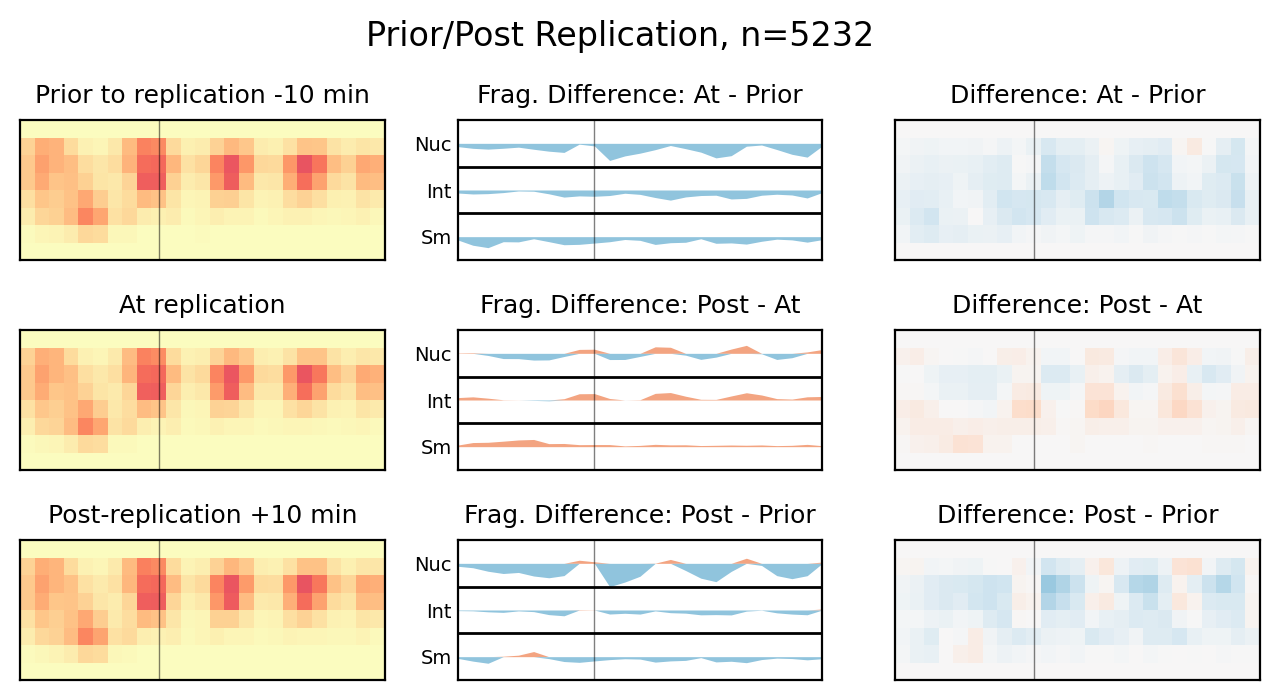

In [9]:
delta_ind = 20

gene_chrom_repl_analysis.select_subset(delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images()

In [17]:
repl_timing_values = gene_chrom_repl_analysis.geneset_repl.replication_timing
repl_timing_values = repl_timing_values.sort_values()

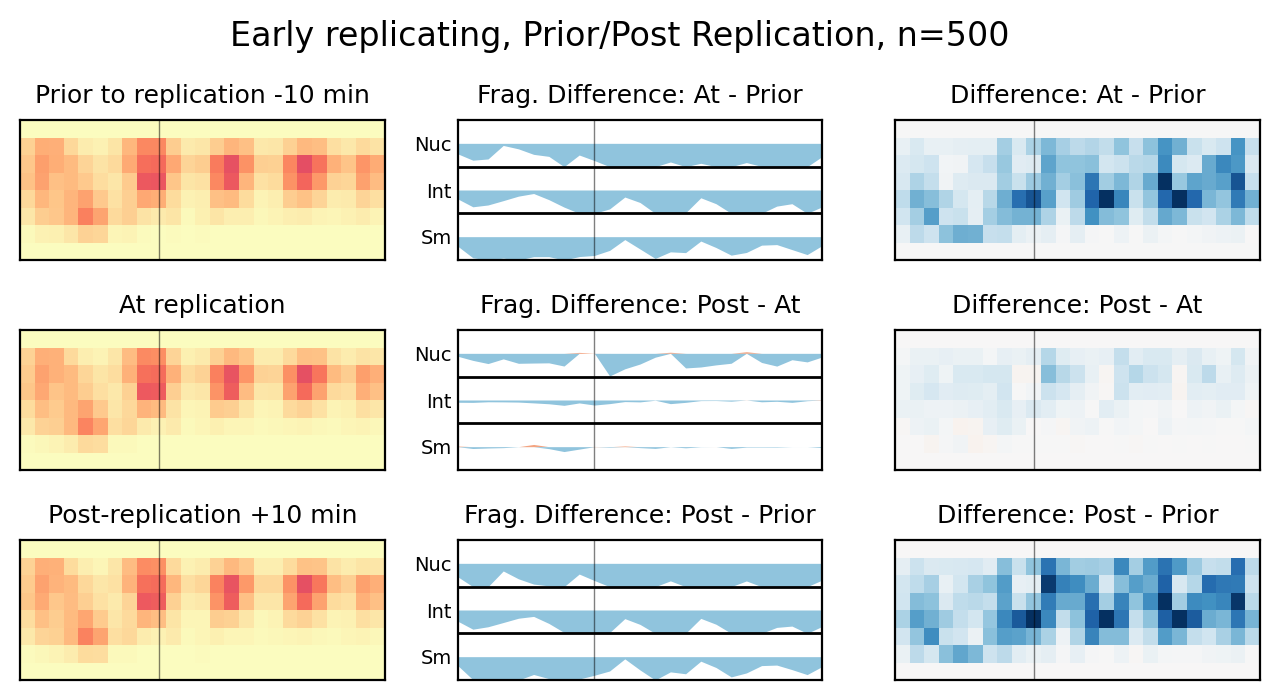

In [18]:
k = 500
gene_chrom_repl_analysis.select_subset(subset_orfs=repl_timing_values.head(k).index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Early replicating")

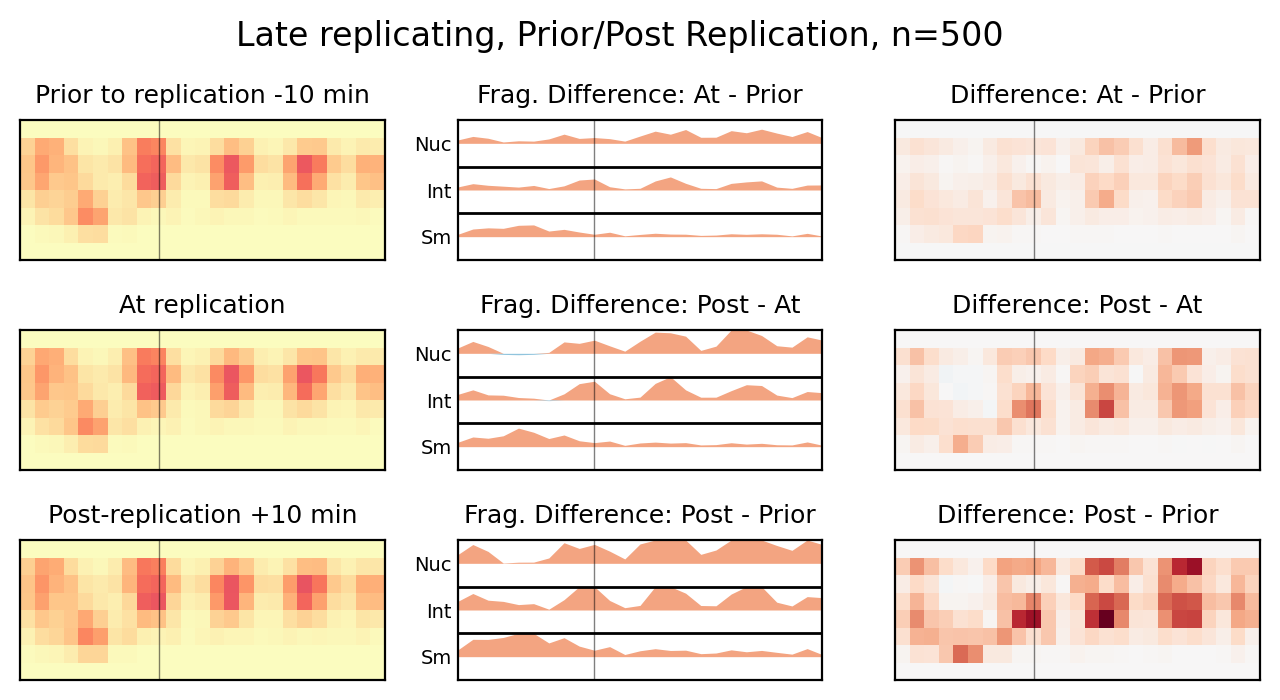

In [19]:
gene_chrom_repl_analysis.select_subset(subset_orfs=repl_timing_values.tail(k).index, 
                                       delta_index=delta_ind)
gene_chrom_repl_analysis.plot_pre_post_images(title="Late replicating")

In [238]:
# Analysis of nucleosome entropy wrt to replication timing

In [143]:
from src.helpers import calc_entropy

In [308]:
def get_gene_nuc_entropy(geneset_sorted_by_repl, orf_names):

    genes = geneset.loc[orf_names]
    gene_f_images = gene_chrom_repl_analysis.\
        sc_f_w_repl_images[genes.f_gene_index].astype(float)

    config = gene_chrom_repl_analysis.config
    t_indices = config.get_Hpositions_for_branch('t')

    small_lens, med_lens, nuc_lens = yl_rep2_len_spans()
    nuc_bins = nuc_lens[0]//GlobalConstants.BIN_HEIGHT, \
        nuc_lens[1]//GlobalConstants.BIN_HEIGHT
    med_bins = med_lens[0]//GlobalConstants.BIN_HEIGHT, \
        med_lens[1]//GlobalConstants.BIN_HEIGHT

    # Get the nucleosomes for all genes and collapse the fragment length dimension
    
    # todo: trying all fragments
    
    
    nucs_over_time = gene_f_images[:, t_indices, med_bins[0]:nuc_bins[1]].sum(axis=2)
    nucs_over_time = nucs_over_time.astype(float)
    nucs_over_time[np.isnan(nucs_over_time)] = 0.
    gene_nuc_entropy = np.apply_along_axis(calc_entropy, 2, nucs_over_time)

    # Z-score normalization
    normalized_gene_nuc_entropy = (gene_nuc_entropy - gene_nuc_entropy.mean(axis=1)\
                                .reshape((-1, 1))) / \
                                gene_nuc_entropy.std(axis=1).reshape((-1, 1))
    return gene_nuc_entropy, normalized_gene_nuc_entropy

In [266]:
def get_repl_positions_in_t(indices_in_t_of_replication):
    config = gene_chrom_repl_analysis.config
    t_timepoints = config.get_timepoints_for_branch('t')
    h_positions = config.get_Hpositions_for_branch('t')
    ret_indices = indices_of_mapping_array(h_positions, 
        indices_in_t_of_replication)
    return ret_indices


In [388]:
def plot_hm(geneset_data, nuc_entropy, title, vmin=-.2, vmax=.2, fig=None):

    if fig is None:
        fig = plt.figure(figsize=(6, 6))

    indices_of_repl = get_repl_positions_in_t(geneset_data.replication_H_index.values)

    nuc_entropy = nuc_entropy[geneset_data.f_gene_index]
    
    plt.imshow(nuc_entropy, aspect='auto', cmap='RdBu_r', vmin=vmin,
               vmax=vmax)

    plt.xlabel("Deconvolved time along mother branch, min")
    plt.xlabel("Deconvolved time, mother branch")
    plt.ylabel("Genes sorted by replication time")

    ys = np.arange(len(geneset_data))
    plt.scatter(indices_of_repl, ys, s=0.5, c='black', marker='D')
    plt.title(f"{title}, n={len(ys)}")
    

In [309]:
geneset_sorted_by_repl = gene_chrom_repl_analysis.geneset_repl.sort_values(
    'replication_timing')
orf_names = geneset_sorted_by_repl.index
gene_nuc_entropy,\
    normalized_gene_nuc_entropy = get_gene_nuc_entropy(geneset_sorted_by_repl, orf_names)

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)


In [328]:
zero_centered_entropy = gene_nuc_entropy - gene_nuc_entropy.mean(axis=1).reshape((-1, 1))

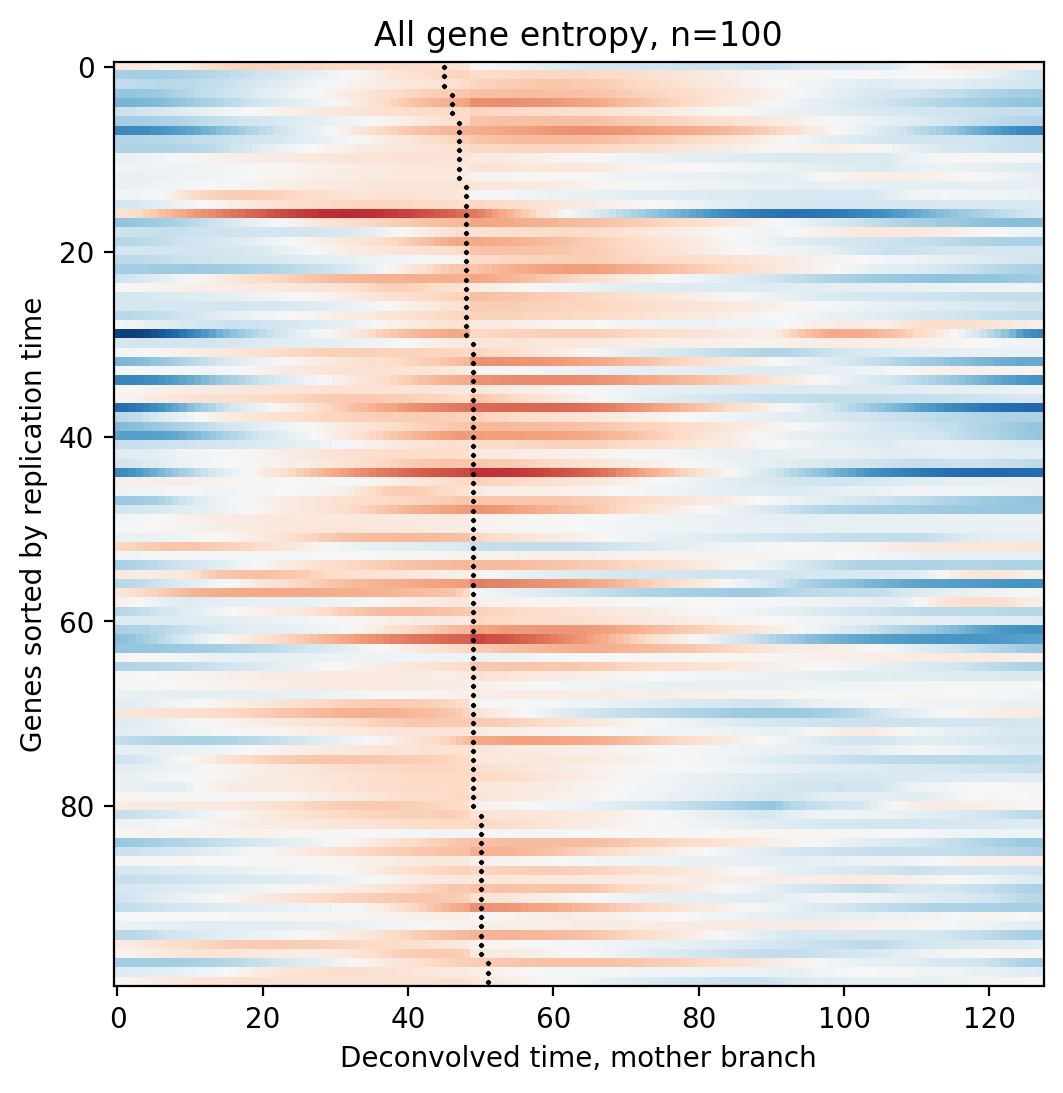

In [330]:
plot_hm(geneset_sorted_by_repl.head(100), zero_centered_entropy[:100], 
        title="All gene entropy", vmin=-.3, vmax=.3)

In [336]:
geneset_sorted_by_repl.head(10)

,gene,TSS,chr,strand,f_gene_index,replication_timing,replication_H_index,expression_at_replication,replication_direction
orf_name,,,,,,,,,
YDR226W,ADK1,916464,4,+,985,26.250585,94,14.185064,right
YDR225W,HTA1,915459,4,+,984,26.250585,94,15.553052,right
YDR224C,HTB1,914747,4,-,983,26.250585,94,15.871309,left
YDR341C,YDR341C,1153663,4,-,1084,26.827785,95,14.099029,early_peak
YDR227W,SIR4,917459,4,+,986,26.827785,95,10.898984,right
YDR223W,CRF1,911654,4,+,982,26.827785,95,6.409247,left
YBR082C,UBC4,407235,2,-,238,27.404885,96,13.115600,right
YBR008C,FLR1,254428,2,-,175,27.404885,96,11.061493,right
YDR222W,YDR222W,910019,4,+,981,27.404885,96,11.609417,left


0

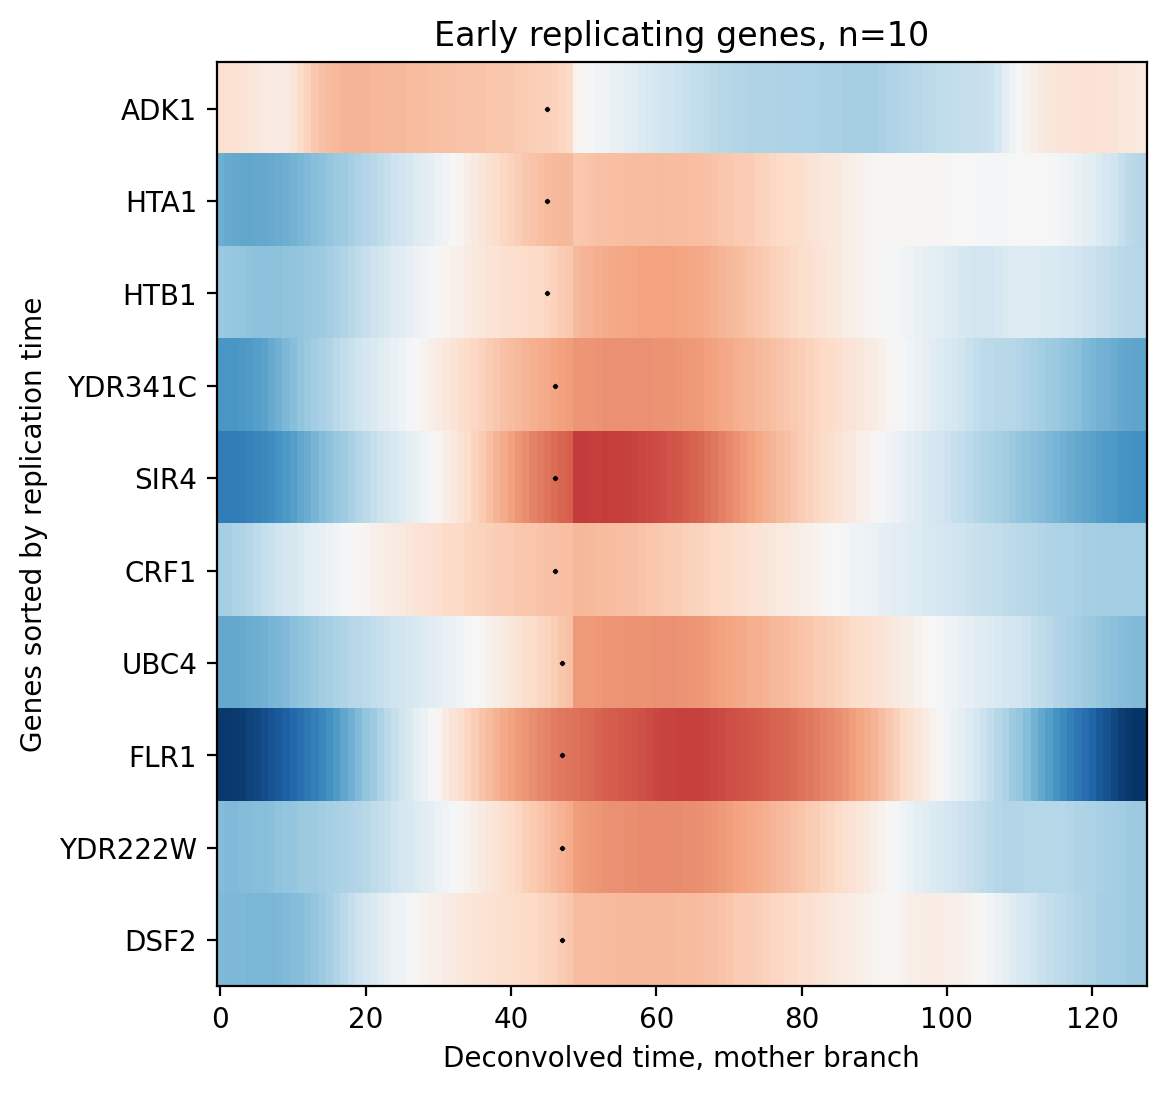

In [352]:
early_genes = geneset_sorted_by_repl.head(10)
plot_hm(early_genes, zero_centered_entropy[:10], 
        title="Early replicating genes", vmin=-.2, vmax=.2)
plt.yticks(np.arange(0, 10), early_genes.gene)
0

0

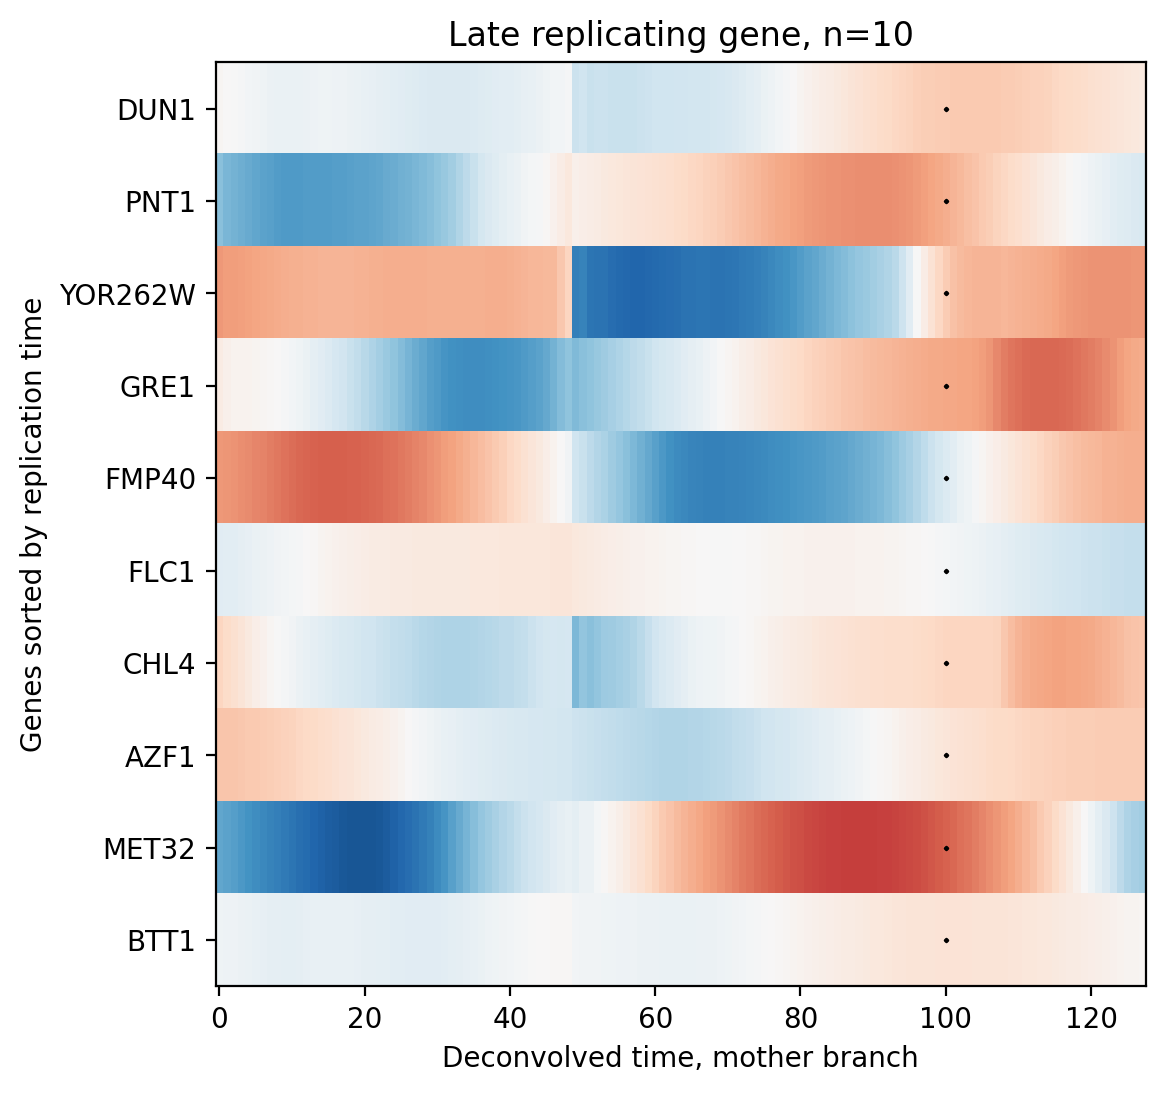

In [350]:
late_genes = geneset_sorted_by_repl.tail(10)
plot_hm(late_genes, zero_centered_entropy[-10:], 
        title="Late replicating gene", vmin=-.2, vmax=.2)
plt.yticks(np.arange(0, 10), late_genes.gene)
0

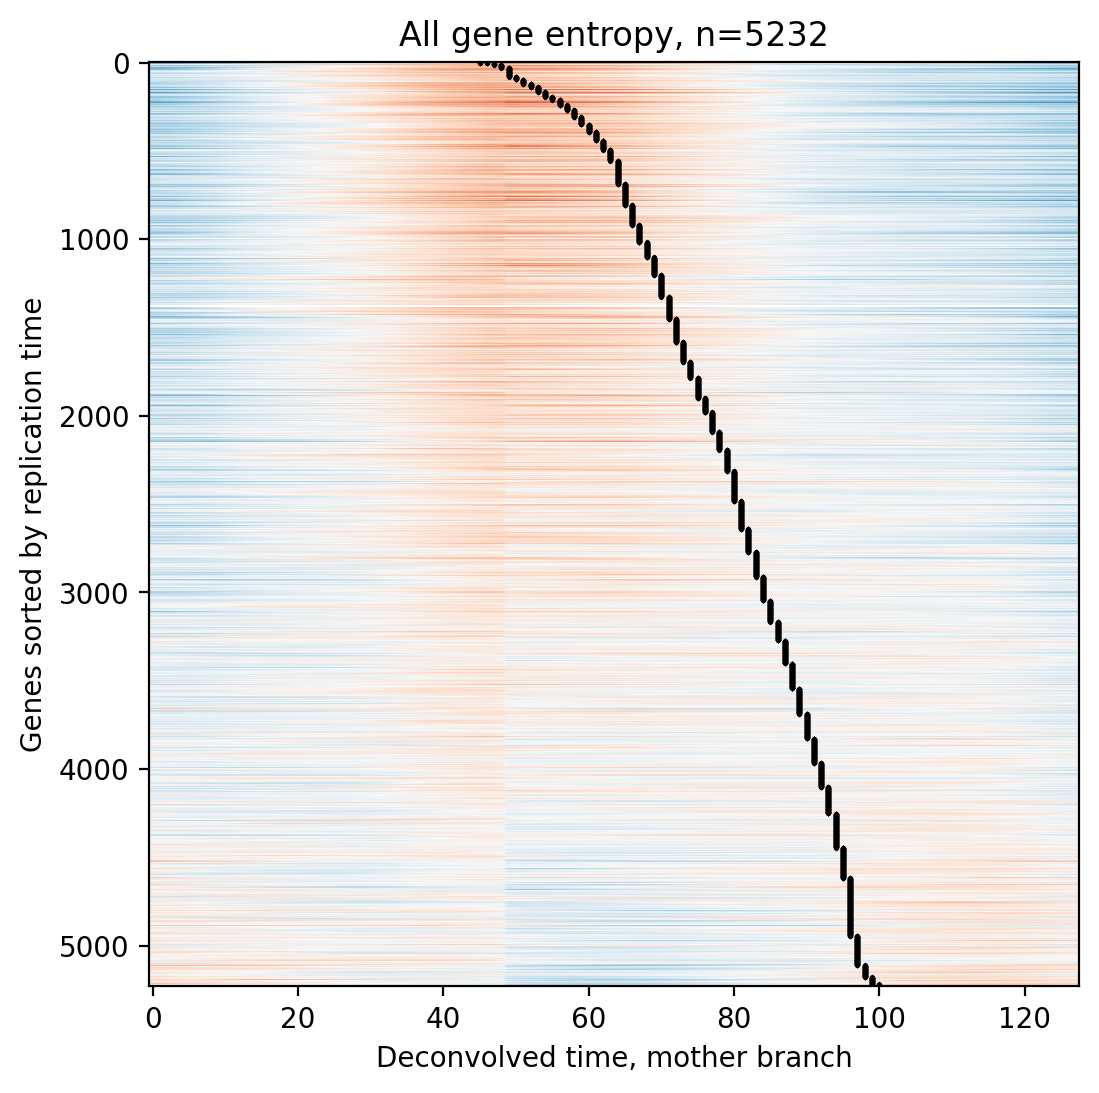

In [351]:
plot_hm(geneset_sorted_by_repl, zero_centered_entropy, title="All gene entropy",
        vmin=-.2, vmax=.2)

In [381]:
k = 500

highly_expressed_genes = geneset_sorted_by_repl.sort_values('expression_at_replication')\
    .head(k)
highly_expressed_genes = highly_expressed_genes.sort_values('replication_timing')

lowly_expressed_genes = geneset_sorted_by_repl.sort_values('expression_at_replication')\
    .tail(k)
lowly_expressed_genes = lowly_expressed_genes.sort_values('replication_timing')


n = len(geneset_sorted_by_repl)
medium_expressed_genes = geneset_sorted_by_repl.sort_values('expression_at_replication')\
    .iloc[(n-k//2):(n+k//2)].sort_values('replication_timing')


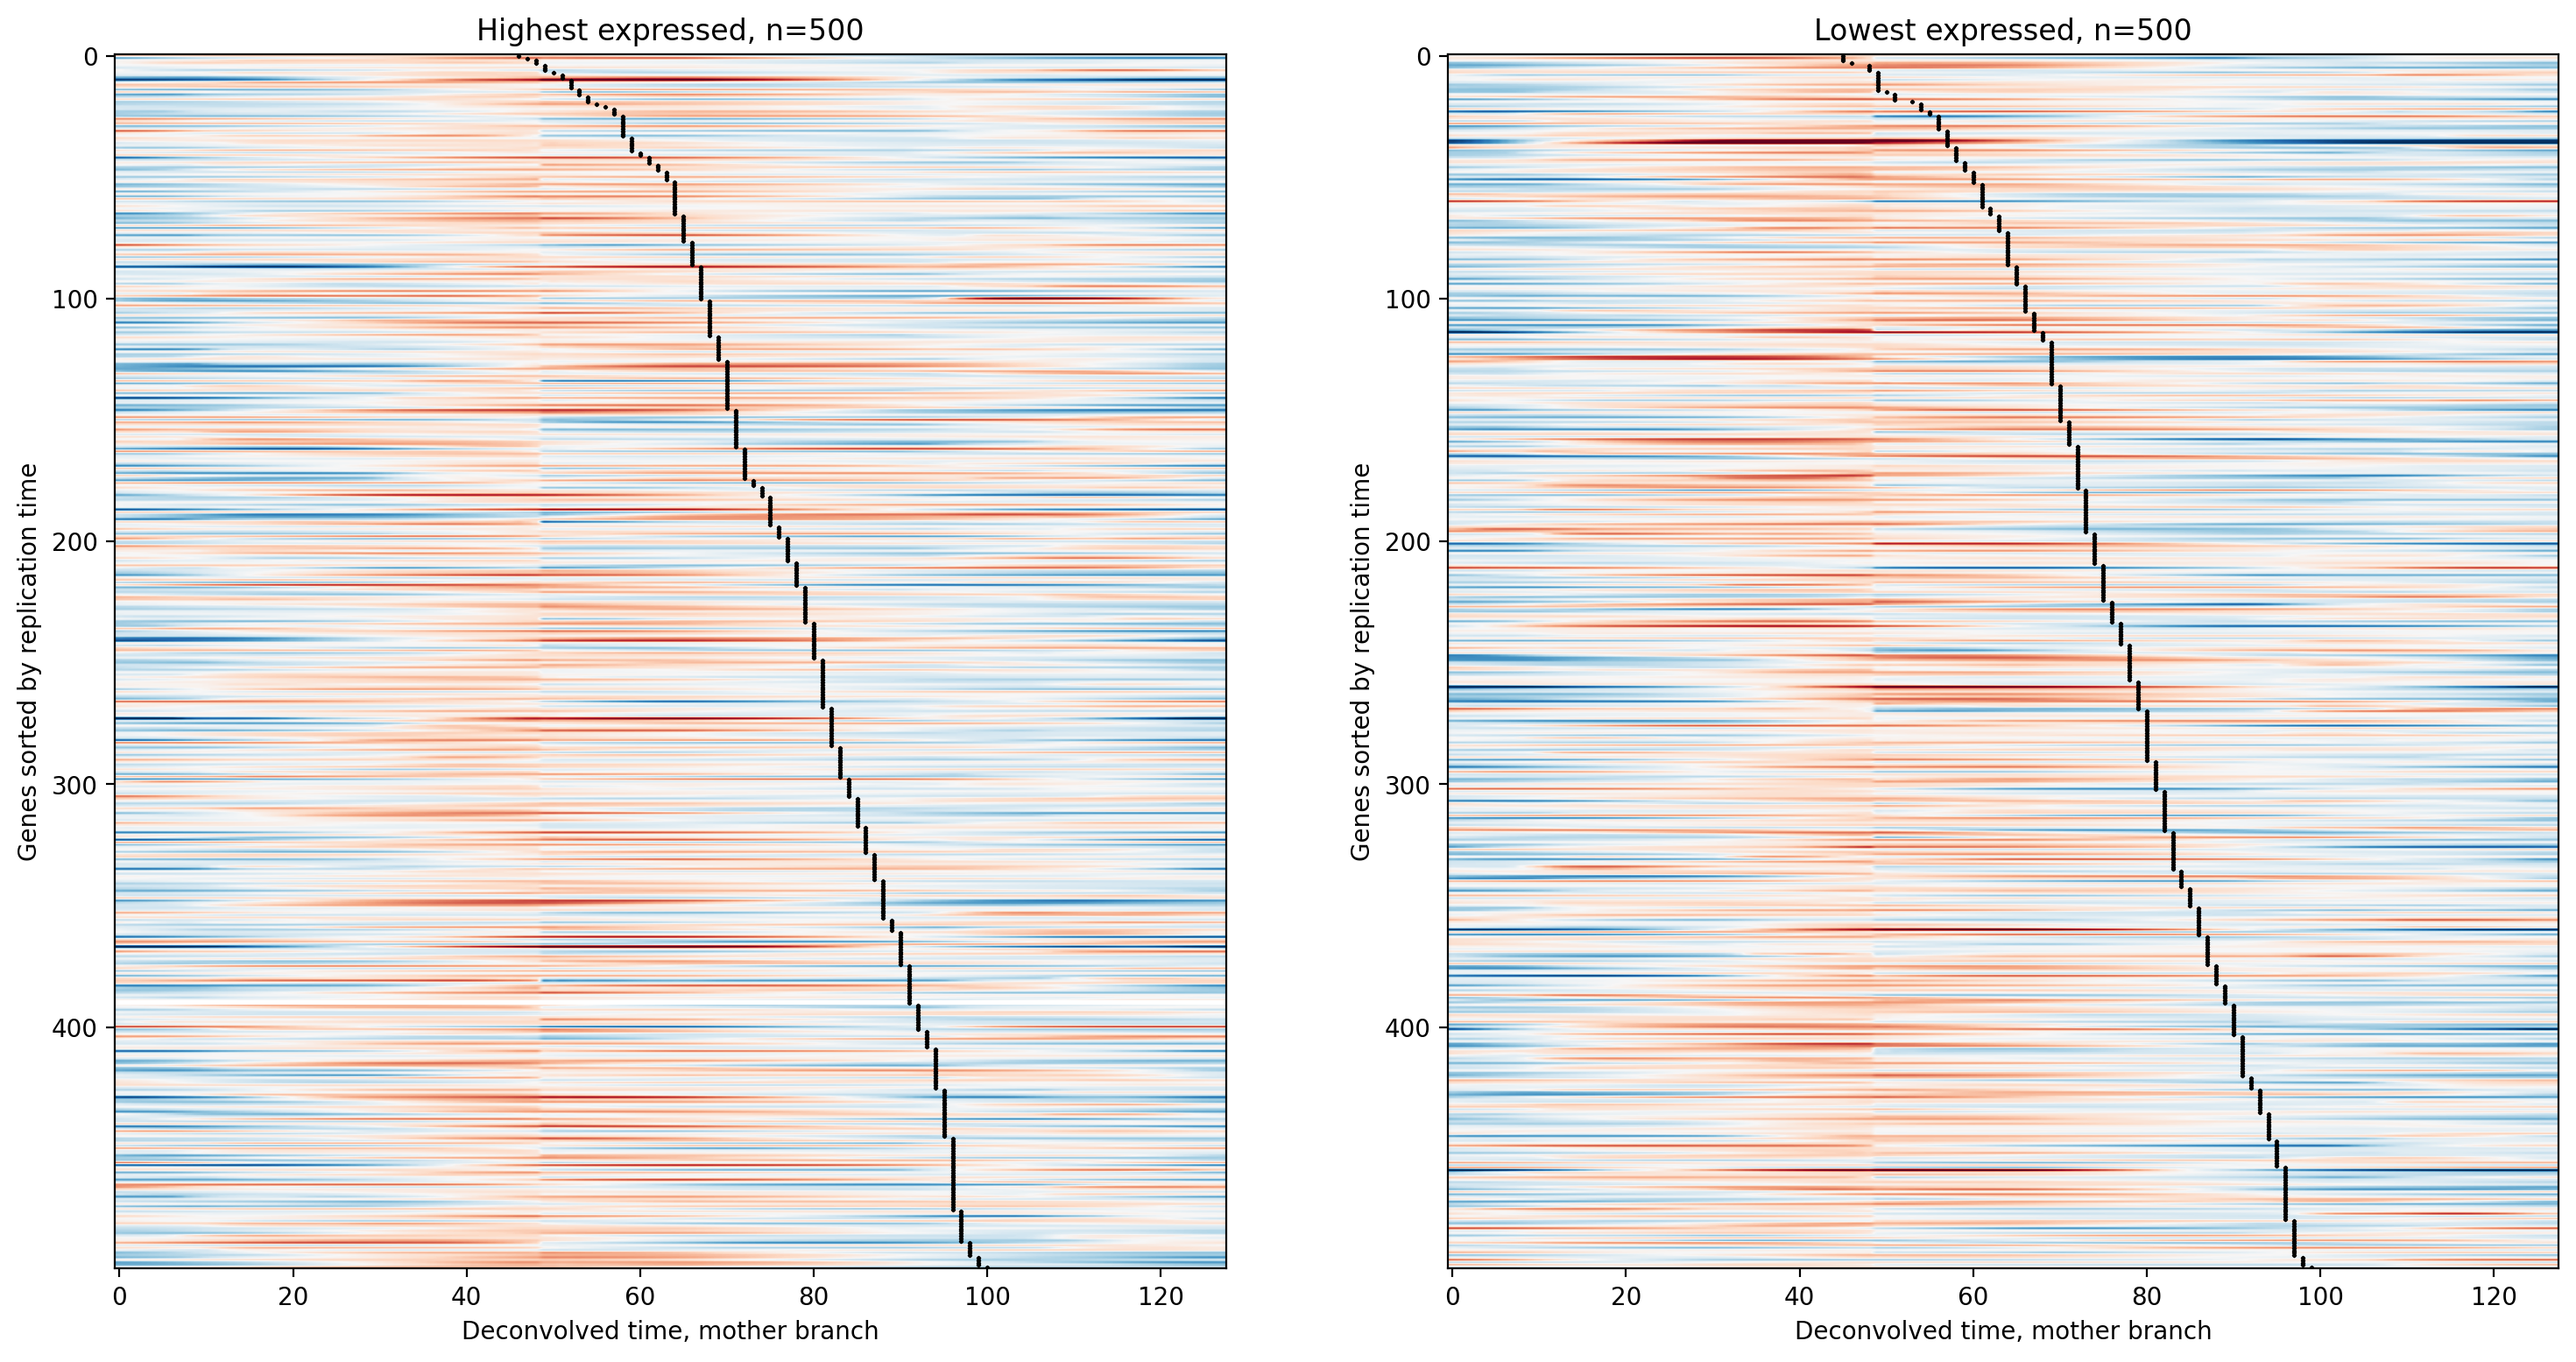

In [396]:
fig = plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)

plot_hm(highly_expressed_genes, zero_centered_entropy, title="Highest expressed",
               vmin=-.2, vmax=.2, fig=fig)
plt.subplot(1, 2, 2)
plot_hm(lowly_expressed_genes, zero_centered_entropy, title="Lowest expressed",
       vmin=-.2, vmax=.2, fig=fig)

In [397]:
# plot_hm(medium_expressed_genes, zero_centered_entropy, title="Medium expressed",
#        vmin=-.2, vmax=.2)

In [ ]:
geneset_repl = geneset_sorted_by_repl

# Filter for highly expressed and late replicating
geneset_repl = geneset_repl[(geneset_repl.expression_at_replication > 12) & 
                            (geneset_repl.replication_timing > 0)]

watson_right = geneset_repl[(geneset_repl.replication_direction == 'right') &
                            (geneset_repl.strand == '+')]
watson_left = geneset_repl[(geneset_repl.replication_direction == 'left') &
                            (geneset_repl.strand == '+')]

crick_right = geneset_repl[(geneset_repl.replication_direction == 'right') &
                            (geneset_repl.strand == '-')]
crick_left = geneset_repl[(geneset_repl.replication_direction == 'left') &
                            (geneset_repl.strand == '-')]

watson_peak = geneset_repl[(geneset_repl.replication_direction == 'early_peak') &
                            (geneset_repl.strand == '+')]
watson_trough = geneset_repl[(geneset_repl.replication_direction == 'late_trough') &
                            (geneset_repl.strand == '+')]


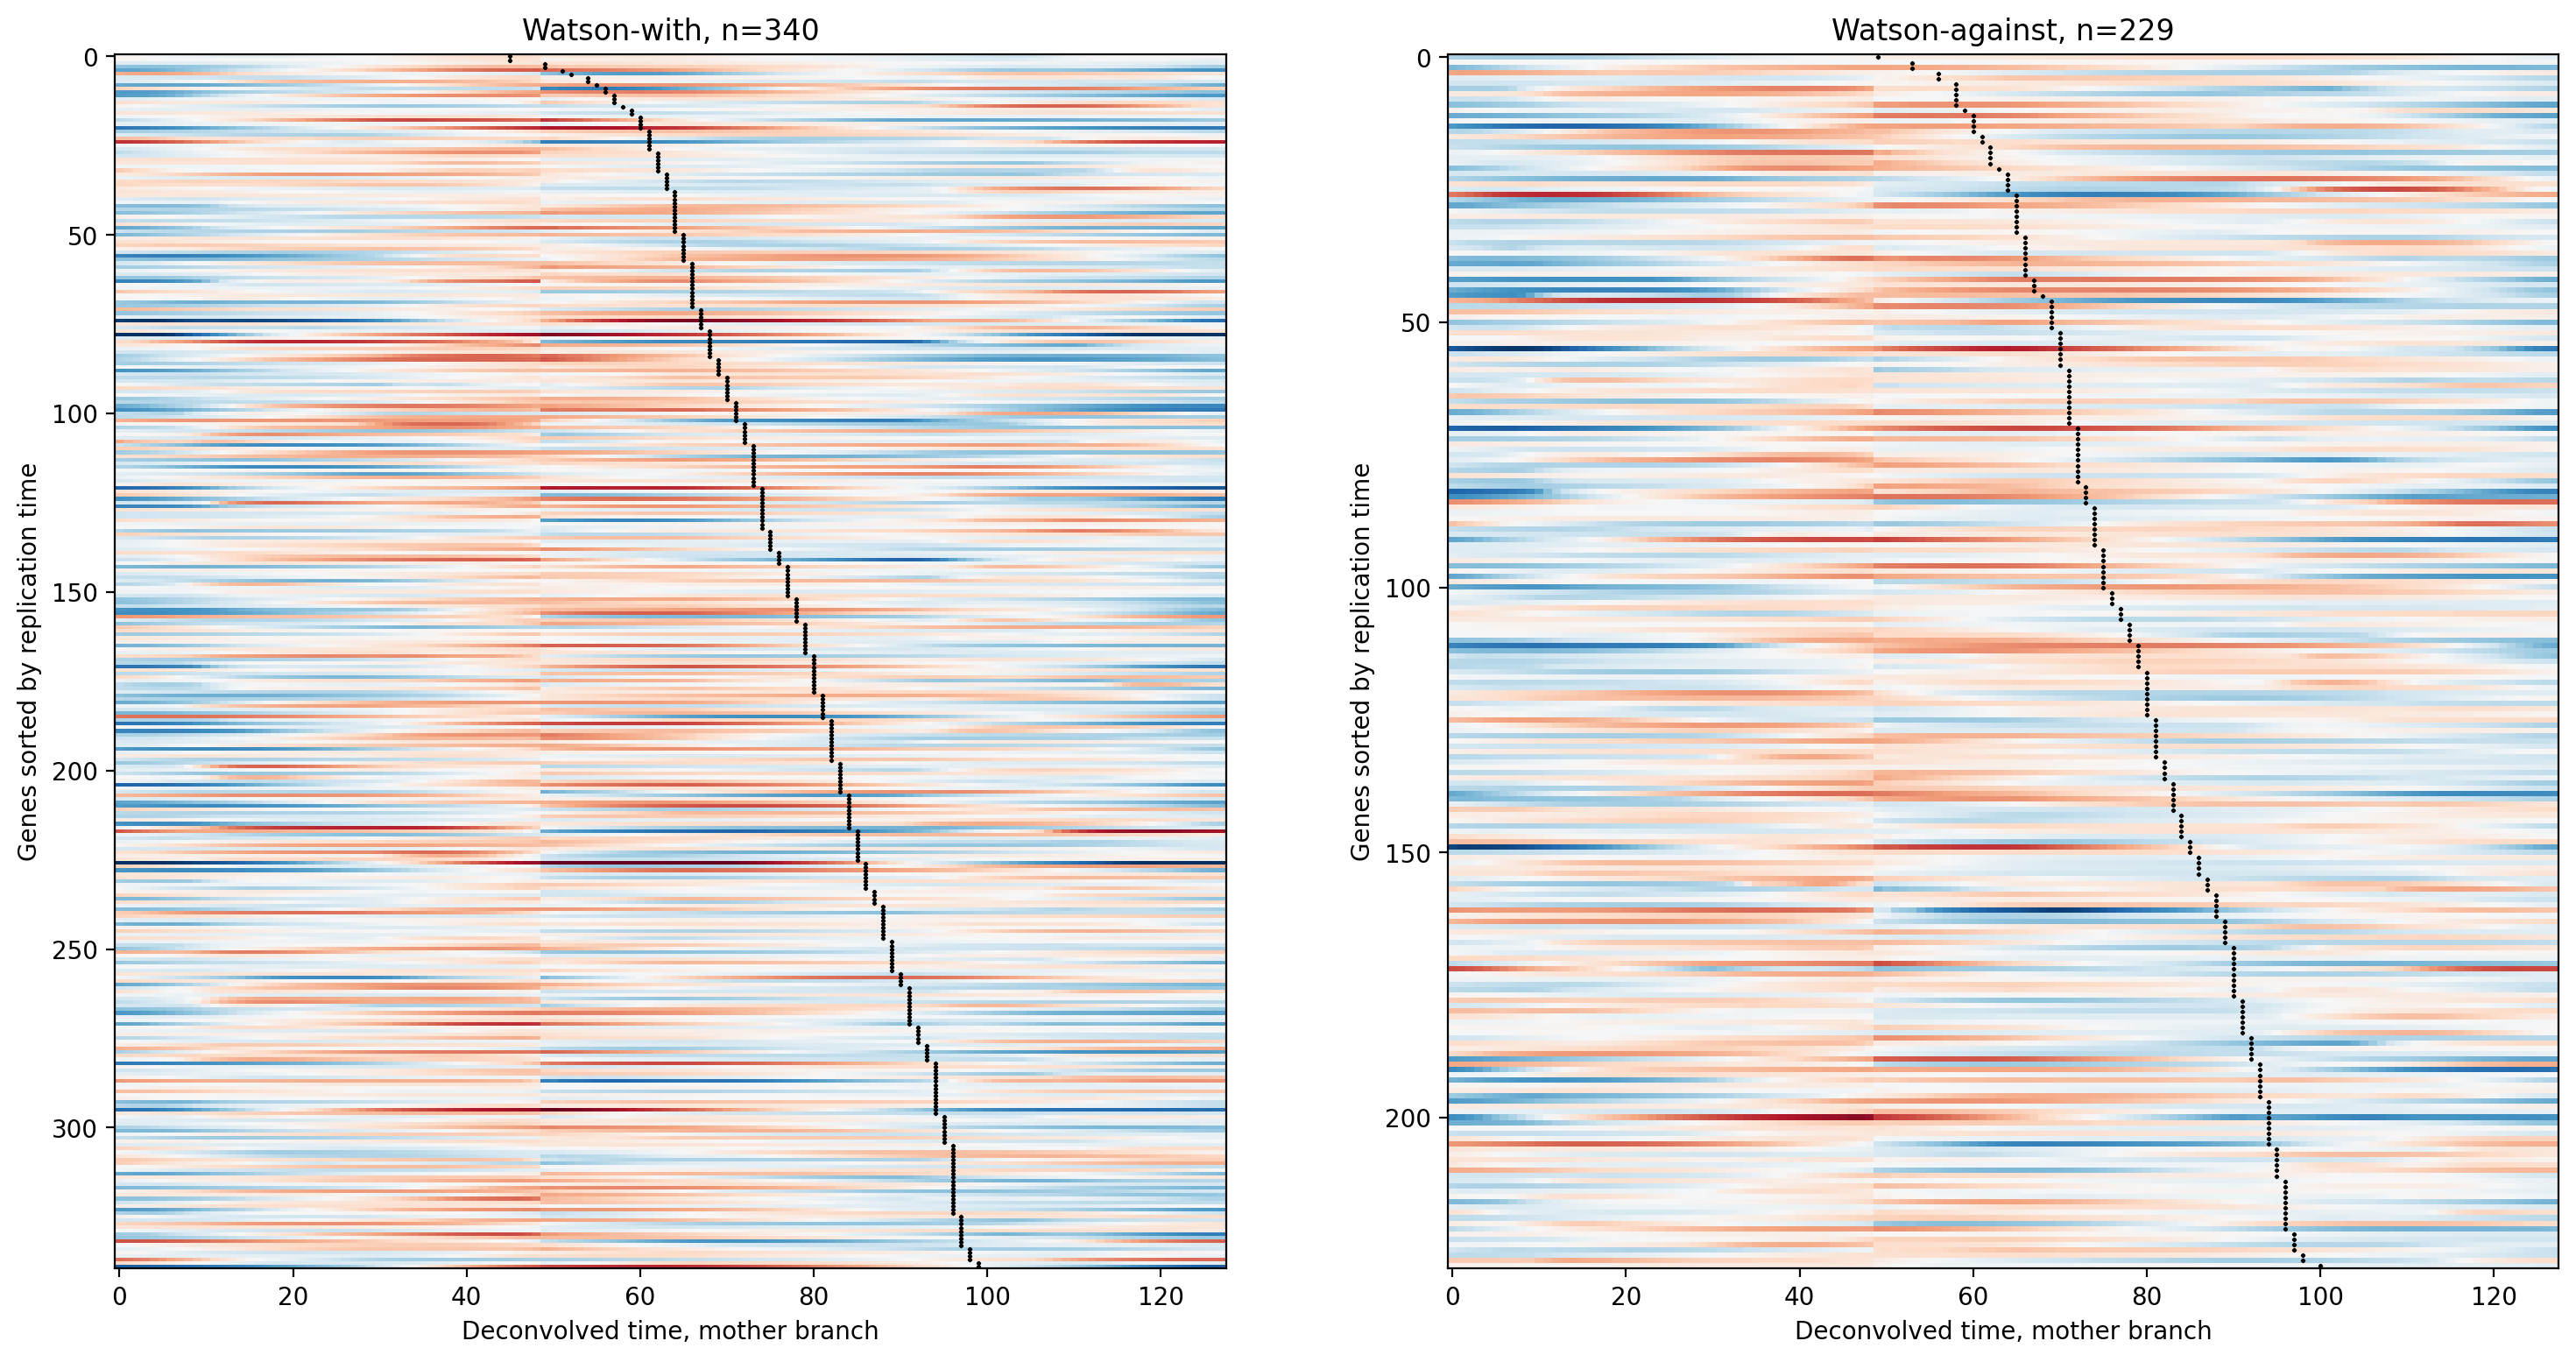

In [392]:
fig = plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)
plot_hm(watson_right.sort_values('replication_timing'),
        zero_centered_entropy, title="Watson-with", fig=fig)

plt.subplot(1, 2, 2)
plot_hm(watson_left.sort_values('replication_timing'),
        zero_centered_entropy, title="Watson-against", fig=fig)

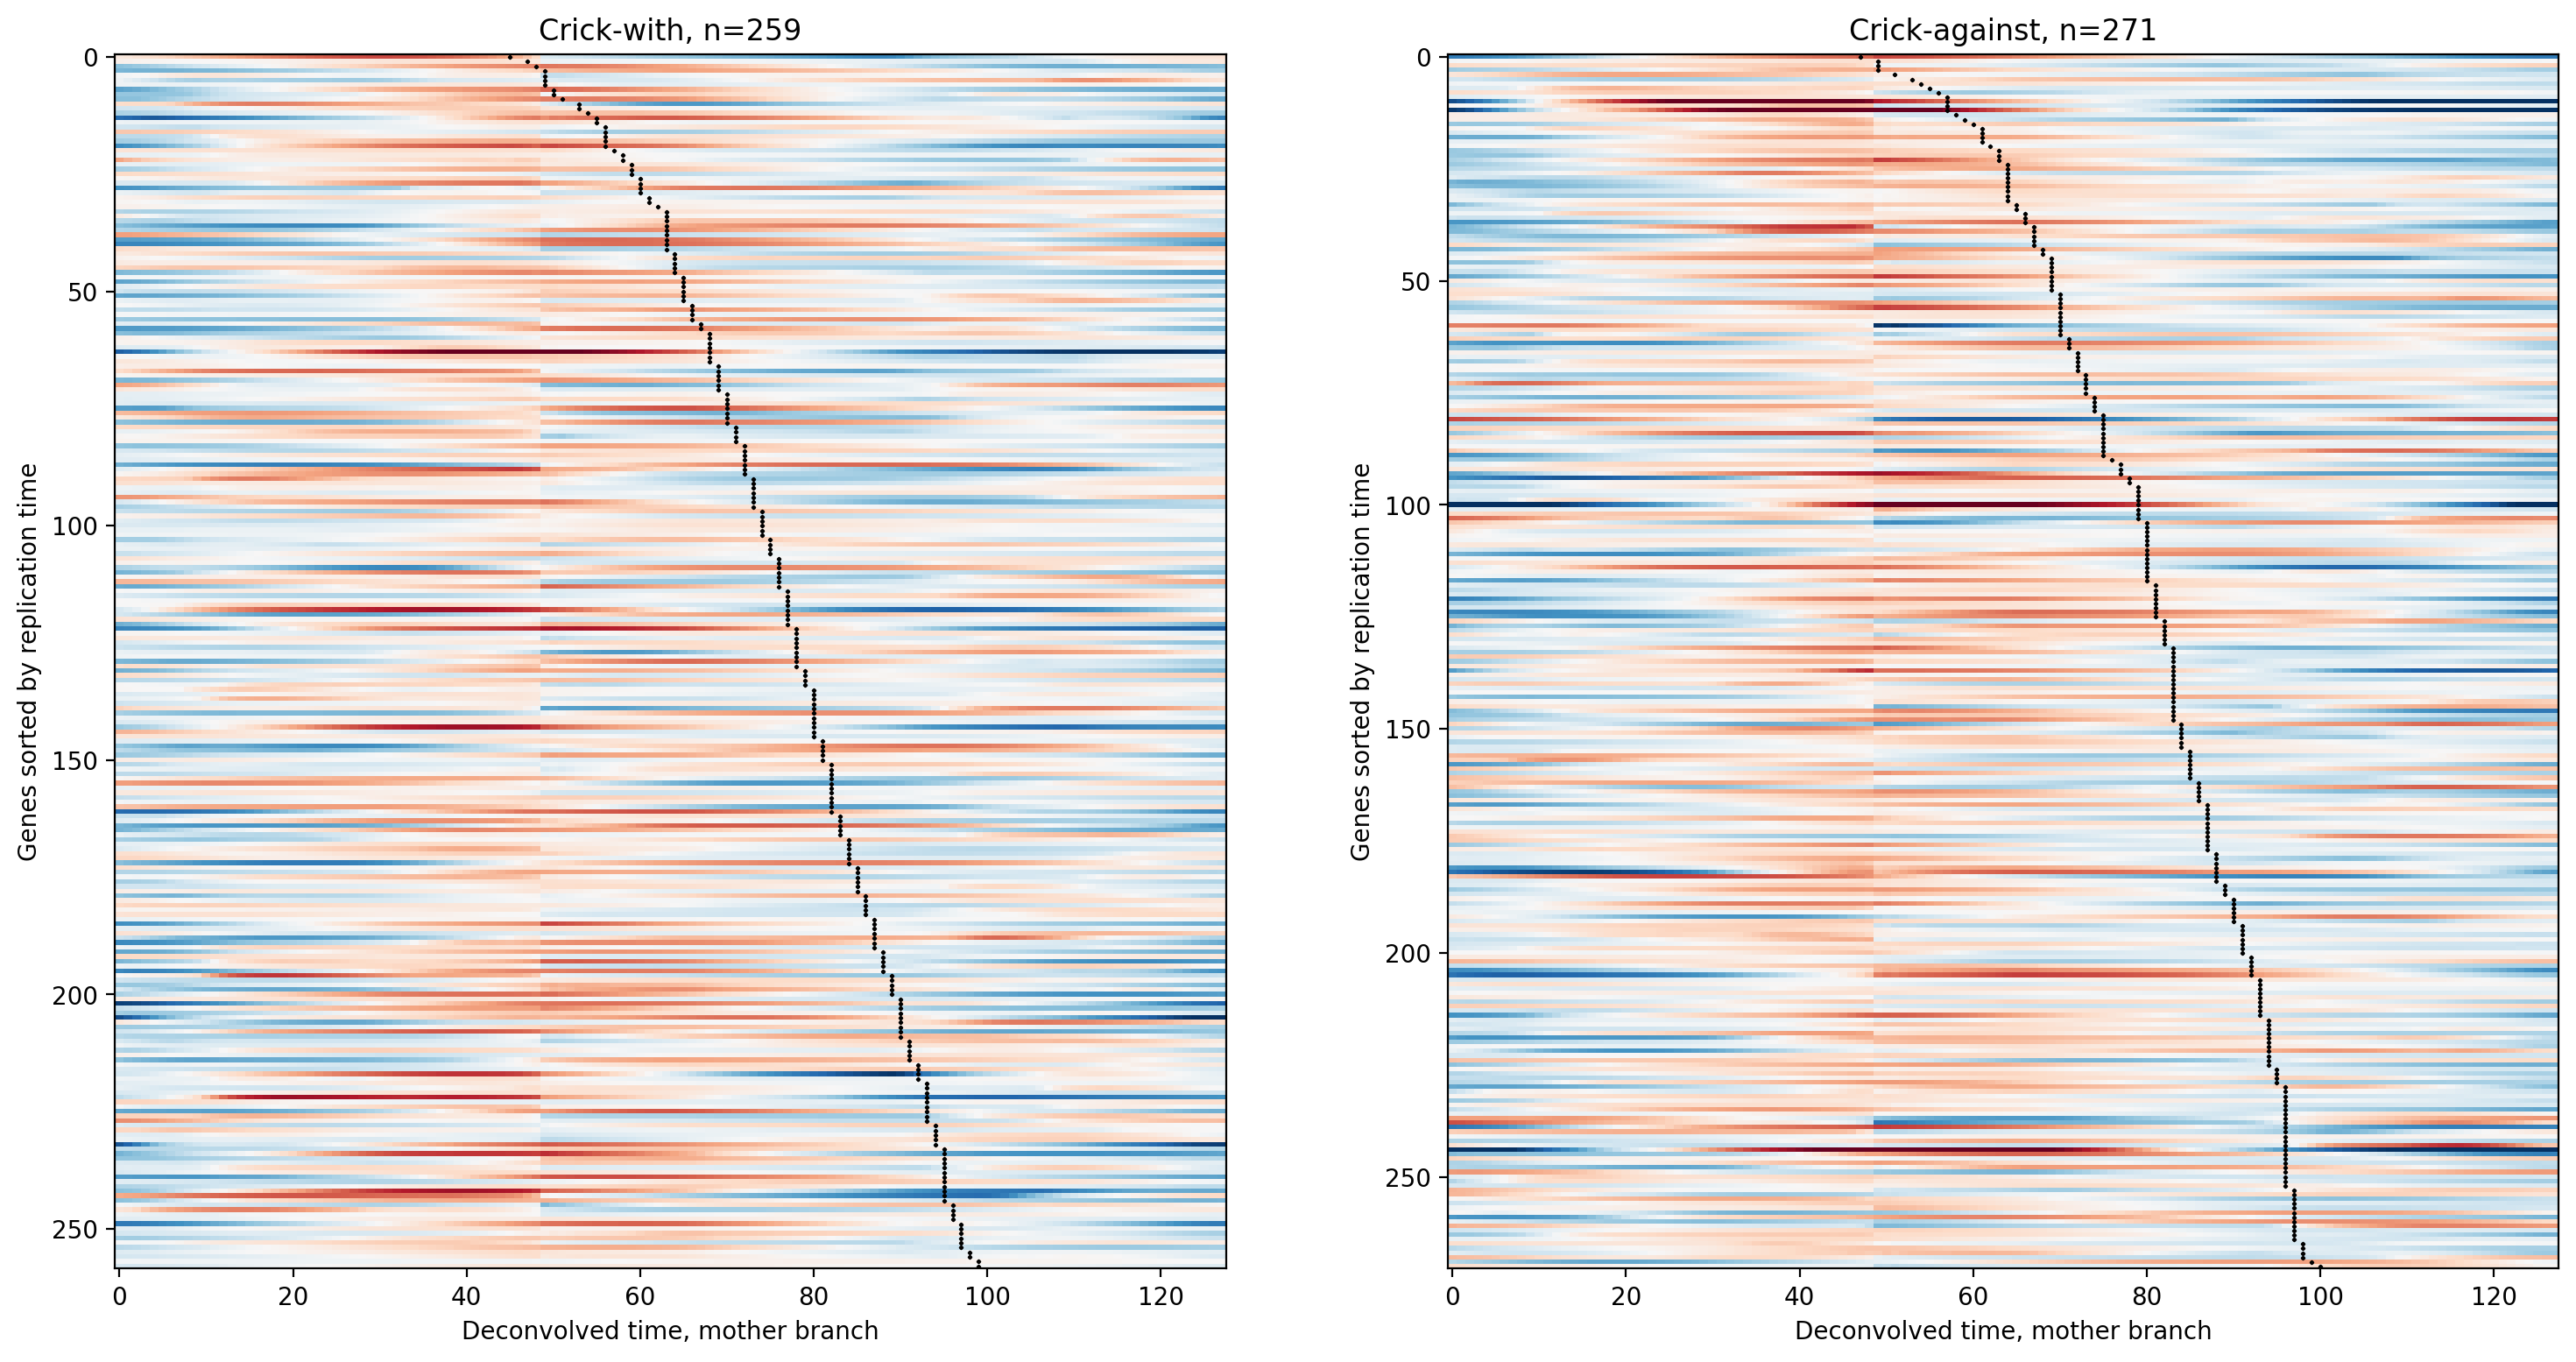

In [393]:
fig = plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)
plot_hm(crick_left.sort_values('replication_timing'),
        zero_centered_entropy, title="Crick-with", fig=fig)

plt.subplot(1, 2, 2)
plot_hm(crick_right.sort_values('replication_timing'),
        zero_centered_entropy, title="Crick-against", fig=fig)